# Análisis de absentismo y bienestar laboral - 08/06/2026

## 1. Pregunta de negocio

> ¿Cómo influyen el consumo social de alcohol o tabaco y los antecedentes disciplinarios en los niveles de absentismo?


## 3. Dataset limpio utilizado y alcance mínimo

Usamos el archivo limpio del corte `08/06/2026`. Esta parte no vuelve a hacer data cleaning; solo controla la muestra que entra en el análisis.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.max_columns', 100)
sns.set_style('white')
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True

# Paleta RRHH Green, alineada con la entrega visual del equipo.
COLOR_VERDE_PRINCIPAL = '#7FB8A4'
COLOR_VERDE_CLARO = '#A8D5C2'
COLOR_VERDE_OSCURO = '#5E9C87'
COLOR_VERDE_MUY_CLARO = '#CFE8DE'
COLOR_GRIS = '#D9D9D9'
COLOR_FONDO = '#FFFFFF'
COLOR_TEXTO = '#2B2B2B'
COLOR_ACENTO_TABLA = '#2E8B57'

# Alias para mantener compatibilidad con gráficos ya creados en el notebook.
COLOR_PRINCIPAL = COLOR_VERDE_OSCURO
COLOR_SECUNDARIO = COLOR_VERDE_PRINCIPAL
COLOR_VERDE_MEDIO = COLOR_VERDE_PRINCIPAL
COLOR_TEAL = COLOR_ACENTO_TABLA
COLOR_OCRE = COLOR_GRIS
COLOR_ALERTA = '#B46B4F'

DATA_FILE = '../../Data/clean/clean_data_01062026.csv'
df_RRHH = pd.read_csv(DATA_FILE)


### Control inicial del dataset

Antes de entrar en el análisis, revisamos tamaño, primeras filas y tipos de datos. Es una comprobación simple, pero ayuda a que el notebook sea trazable y no funcione como una caja negra.


In [2]:
print('Filas y columnas:', df_RRHH.shape)
display(df_RRHH.head())
df_RRHH.info()


Filas y columnas: (844, 28)


,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
0,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,12,14,34,284.031,97,0,1,Secundaria,2,1,0,0,95,196,25,24.7,120,2026-05-25
1,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,13,18,50,239.409,98,0,1,Secundaria,1,1,0,0,98,178,31,30.9,120,2026-05-25
2,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,14,16,58,264.604,93,0,1,Secundaria,2,0,0,1,65,172,22,22.0,120,2026-05-25
3,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,26,9,28,230.290,92,0,1,Secundaria,1,0,0,2,69,169,24,24.2,112,2026-05-25
4,9,12.0,Piel y tejido subcutáneo,9.0,Septiembre,3,Martes,3,Verano,228,14,16,58,222.196,99,0,1,Secundaria,2,0,0,1,65,172,22,22.0,112,2026-05-25


<class 'pandas.DataFrame'>
RangeIndex: 844 entries, 0 to 843
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       844 non-null    int64  
 1   Reason_absence           802 non-null    float64
 2   Reason_absence_name      802 non-null    str    
 3   Month_absence            841 non-null    float64
 4   Month_absence_name       841 non-null    str    
 5   Day_week                 844 non-null    int64  
 6   Day_week_name            844 non-null    str    
 7   Seasons                  844 non-null    int64  
 8   Seasons_name             844 non-null    str    
 9   Transportation_expense   844 non-null    int64  
 10  Distance_Residence_Work  844 non-null    int64  
 11  Service_time             844 non-null    int64  
 12  Age                      844 non-null    int64  
 13  Work_load_Average_day    844 non-null    float64
 14  Hit_target               844 non-null

In [3]:
alcance = pd.DataFrame({
    'métrica': [
        'registros limpios',
        'IDs observados',
        'horas totales de absentismo',
        'registros con ausencia > 0 horas'
    ],
    'valor': [
        len(df_RRHH),
        df_RRHH['ID'].nunique(),
        df_RRHH['Absenteeism_hours'].sum(),
        (df_RRHH['Absenteeism_hours'] > 0).sum()
    ]
})

alcance


,métrica,valor
0,registros limpios,844
1,IDs observados,136
2,horas totales de absentismo,6226
3,registros con ausencia > 0 horas,801


**Lectura:** el análisis trabaja con el clean consolidado del 01/06/2026. Las métricas describen la muestra disponible, no la plantilla completa de RapidExpress.


## 4. Variables consideradas

**Variables personales:** `Social_drinker`, `Social_smoker`.

**Variables laborales:** `Disciplinary_failure`.



> No estamos buscando “culpables” ni perfiles individuales cerrados. Estamos ordenando variables para ver dónde aparecen asociaciones y qué preguntas internas podría hacerse RRHH.


## 5. Construcción de absentismo elevado

Para comparar segmentos usamos una vista agregada por `ID`. Definimos `absentismo_elevado` como los IDs situados en el cuartil superior de horas acumuladas.

Este criterio no es un diagnóstico individual ni un modelo predictivo. Es una regla exploratoria, fácil de explicar y útil para comparar grupos de forma transparente.


In [17]:
df_empleados = df_RRHH.groupby('ID', as_index=False).agg(
    registros=('ID', 'size'),
    horas_totales=('Absenteeism_hours', 'sum'),
    media_horas=('Absenteeism_hours', 'mean'),
    Age=('Age', 'first'),
    Education_name=('Education_name', 'first'),
    Son=('Son', 'first'),
    Pet=('Pet', 'first'),
    Social_drinker=('Social_drinker', 'first'),
    Social_smoker=('Social_smoker', 'first'),
    BMI_calculated=('BMI_calculated', 'first'),
    Service_time=('Service_time', 'first'),
    Distance_Residence_Work=('Distance_Residence_Work', 'first'),
    Transportation_expense=('Transportation_expense', 'first'),
    Work_load_Average_day=('Work_load_Average_day', 'median'),
    Hit_target=('Hit_target', 'median'),
    Disciplinary_failure=('Disciplinary_failure', 'max')
)

umbral_absentismo_elevado = df_empleados['horas_totales'].quantile(0.75)
df_empleados['absentismo_elevado'] = df_empleados['horas_totales'] >= umbral_absentismo_elevado

print('Umbral de absentismo elevado:', umbral_absentismo_elevado, 'horas')
print('IDs con absentismo elevado:', df_empleados['absentismo_elevado'].sum())
print('IDs observados:', df_empleados['ID'].nunique())

df_empleados.sort_values('horas_totales', ascending=False)


Umbral de absentismo elevado: 16.0 horas
IDs con absentismo elevado: 37
IDs observados: 136


,ID,registros,horas_totales,media_horas,Age,Education_name,Son,Pet,Social_drinker,Social_smoker,BMI_calculated,Service_time,Distance_Residence_Work,Transportation_expense,Work_load_Average_day,Hit_target,Disciplinary_failure,absentismo_elevado
13,14,30,596,19.866667,34,Secundaria,2,0,1,0,24.7,14,12,155,304.465,96.0,0,True
8,9,10,494,49.400000,58,Secundaria,2,1,0,0,22.0,16,14,228,255.339,96.5,0,True
2,3,113,482,4.265487,38,Secundaria,0,0,1,0,30.8,18,51,179,253.465,96.0,1,True
27,28,77,459,5.961039,28,Secundaria,1,2,0,0,24.2,9,26,225,280.549,95.0,1,True
10,11,40,450,11.250000,33,Secundaria,2,1,1,0,30.4,13,36,289,265.316,93.5,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,87,1,1,1.000000,37,Secundaria,0,0,0,0,28.1,10,10,118,308.593,95.0,0,False
124,125,1,1,1.000000,50,Secundaria,1,0,1,0,30.9,18,13,118,230.290,92.0,0,False
3,4,1,0,0.000000,40,Secundaria,1,8,1,0,33.9,13,14,118,271.219,95.0,0,False
7,8,2,0,0.000000,39,Secundaria,2,2,1,0,34.6,14,35,231,282.718,88.0,1,False


**Lectura:** el cuartil superior permite separar los IDs con más horas acumuladas para comparar segmentos. 
No significa que esos IDs sean “de riesgo”; solo indica mayor carga registrada dentro de la muestra.


**Verificación importante sobre `Disciplinary_failure`:** esta variable indica si hay una nota/fallo disciplinario. En el dataset, las filas con `Disciplinary_failure = 1` tienen `Absenteeism_hours = 0`. Por tanto, no se interpreta como horas de absentismo ni como causa directa de ausencia. Al agregar por `ID` usamos `max` solo para saber si ese ID tuvo alguna nota disciplinaria en la muestra.

In [5]:
pd.crosstab(df_RRHH['Disciplinary_failure'], df_RRHH['Absenteeism_hours'])

Absenteeism_hours,0,1,2,3,4,5,7,8,16,24,32,40,48,56,64,80,104,112,120
Disciplinary_failure,,,,,,,,,,,,,,,,,,,
0,4,101,183,127,66,7,1,243,22,17,7,7,1,2,3,3,1,4,6
1,39,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 6. Asociaciones con variables personales y laborales

Primero recuperamos el enfoque de `analisis_perfil`: comparar absentismo medio por variables categóricas y revisar correlaciones en variables numéricas.

La lectura esperada no es causal. Buscamos si alguna variable muestra una diferencia suficientemente clara como para orientar preguntas internas.


In [15]:
def comparar_absentismo(df, variable):
    resultado = (
        df.groupby(variable)['horas_totales']
        .mean()
        .round(2)
        .reset_index()
        .sort_values(by='horas_totales', ascending=False)
    )

    conteo = df[variable].value_counts()

    print("\nRecuento por grupo:")
    print(conteo)

    print("\nAbsentismo medio por grupo:")
    print(resultado)

    plt.figure(figsize=(8, 5))
    plt.gcf().patch.set_alpha(0)
    ax = plt.gca()
    ax.set_facecolor('none')
    sns.barplot(data=resultado, x=variable, y='horas_totales', color=COLOR_TEAL)
    plt.title(f'Absentismo medio por {variable}')
    plt.ylabel('Horas promedio de absentismo')
    plt.xlabel(variable)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



Recuento por grupo:
Disciplinary_failure
0    116
1     20
Name: count, dtype: int64

Absentismo medio por grupo:
   Disciplinary_failure  horas_totales
1                     1         169.90
0                     0          24.38


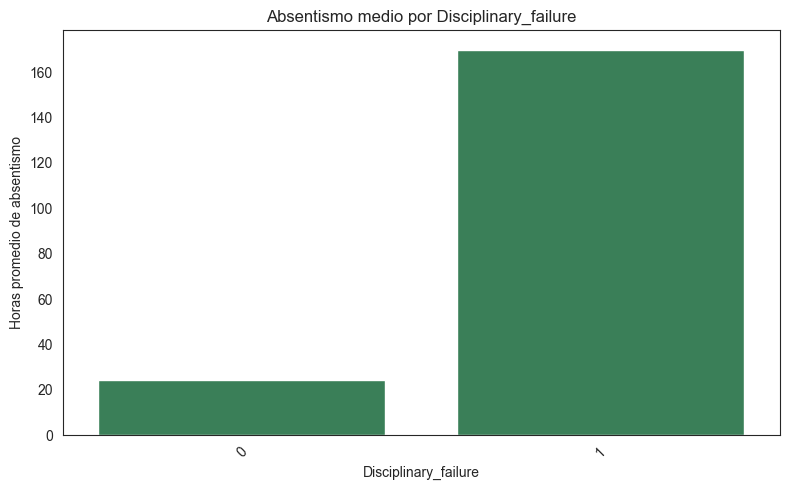

In [18]:
comparar_absentismo(df_empleados, 'Disciplinary_failure')



Recuento por grupo:
Social_drinker
1    71
0    65
Name: count, dtype: int64

Absentismo medio por grupo:
   Social_drinker  horas_totales
1               1          53.06
0               0          37.83


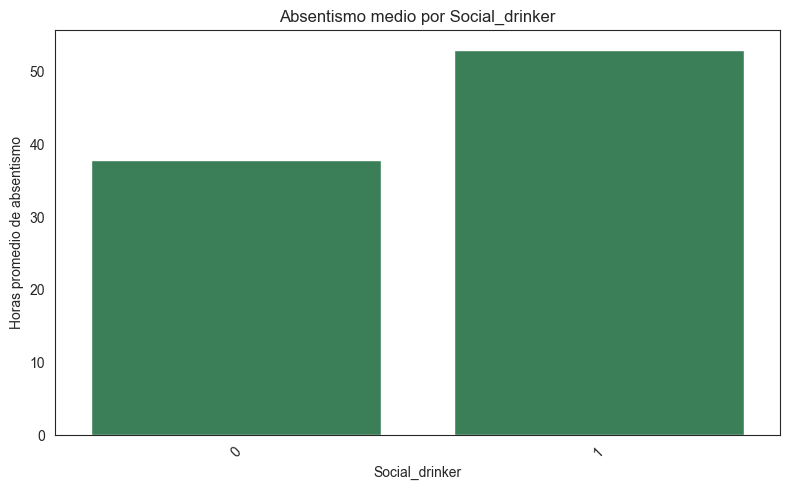

In [19]:
comparar_absentismo(df_empleados, 'Social_drinker')



Recuento por grupo:
Social_smoker
0    122
1     14
Name: count, dtype: int64

Absentismo medio por grupo:
   Social_smoker  horas_totales
0              0          47.83
1              1          27.93


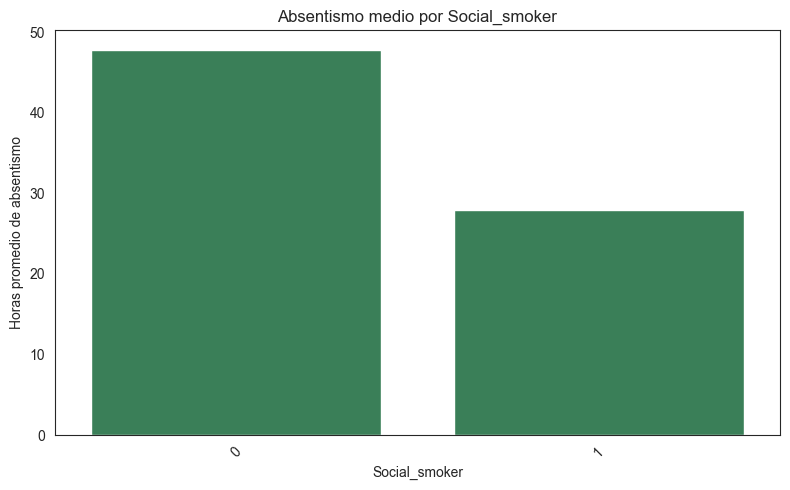

In [20]:
comparar_absentismo(df_empleados, 'Social_smoker')


**Lectura:** las comparaciones por grupos muestran diferencias, pero no bastan para afirmar causalidad. Algunos grupos son pequeños y pueden estar afectados por pocos IDs con muchas horas.


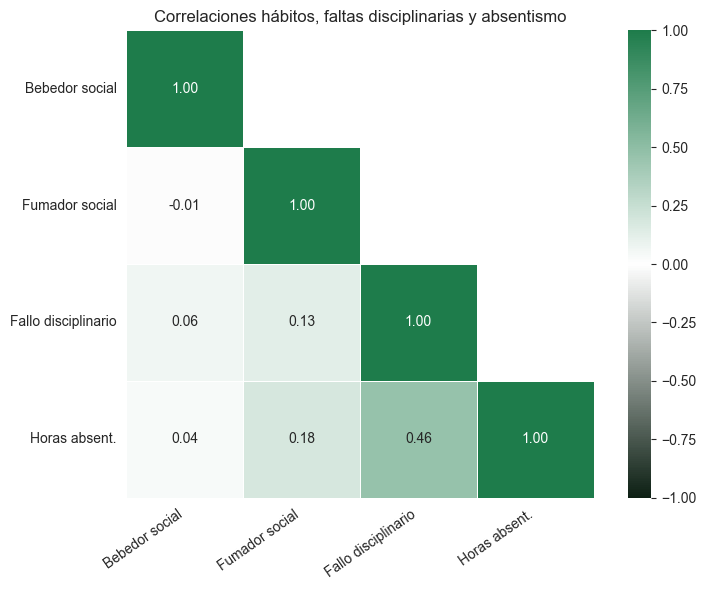

In [49]:
variables_corr = [
    'Social_drinker', 'Social_smoker', 'Disciplinary_failure', 'horas_totales'
]

corr = df_empleados[variables_corr].corr(method='spearman')

labels_es = {
    'Social_drinker': 'Bebedor social',
    'Social_smoker': 'Fumador social',
    'Disciplinary_failure': 'Fallo disciplinario',
    'horas_totales': 'Horas absent.'
}

corr = corr.rename(index=labels_es, columns=labels_es)

cmap_verde = LinearSegmentedColormap.from_list(
    'verde_blanco_verde', ['#0d2014', '#ffffff', '#1e7c4b']
)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(8, 6), facecolor='none')
plt.gcf().patch.set_alpha(0)
ax = sns.heatmap(
    corr, annot=True, fmt='.2f', cmap=cmap_verde, center=0,
    mask=mask, square=True, vmin=-1, vmax=1, linewidths=0.5
)
ax.set_facecolor('none')
plt.title('Correlaciones hábitos, faltas disciplinarias y absentismo')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [24]:
correlacion_absentismo = (
    corr[['Horas absent.']]
    .drop(index='Horas absent.')
    .sort_values('Horas absent.', key=abs, ascending=False)
)

correlacion_absentismo


,Horas absent.
Fallo disciplinario,0.464952
Fumador social,0.181462
Bebedor social,0.036291


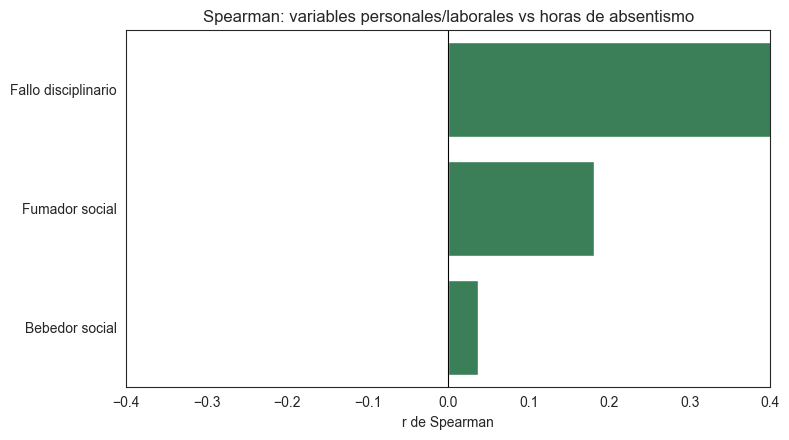

In [25]:
correlacion_plot = (
    correlacion_absentismo
    .reset_index()
    .rename(columns={'index': 'variable', 'Horas absent.': 'r_spearman'})
)

plt.figure(figsize=(8, 4.5))
plt.gcf().patch.set_alpha(0)
ax = plt.gca()
ax.set_facecolor('none')
colores = [COLOR_TEAL if valor >= 0 else COLOR_OCRE for valor in correlacion_plot['r_spearman']]

sns.barplot(
    data=correlacion_plot,
    y='variable',
    x='r_spearman',
    palette=colores,
    hue='variable',
    legend=False
)

plt.axvline(0, color='black', linewidth=0.8)
plt.xlim(-0.4, 0.4)
plt.title('Spearman: variables personales/laborales vs horas de absentismo')
plt.xlabel('r de Spearman')
plt.ylabel('')
plt.tight_layout()
plt.show()


**Lectura del gráfico Spearman:** las barras muestran la fuerza y dirección de la asociación entre cada variable y las horas acumuladas de absentismo. Podemos observar que la correlación por Fallo disciplinario es la más alta, aunque sigue siendo moderada.


**Lectura:** las correlaciones con absentismo son débiles. La señal más alta queda lejos de una relación fuerte, así que no sería riguroso afirmar que una variable personal o laboral explica por sí sola las ausencias.

Esto no invalida el análisis. Al contrario: ayuda a descartar una explicación demasiado simple y empuja a mirar segmentos, motivos y concentración de horas.


## 6.1. Contrastes estadísticos por variable

Para cerrar mejor la pregunta de negocio, además de correlaciones se aplican tests no paramétricos similares a los usados en `Analisis_perfil` por Noelia y Sabina.

La unidad de análisis en esta sección es `df_empleados`, es decir, una fila por `ID`. Esto evita que una persona con muchos registros pese más que otra solo por aparecer más veces en el dataset. Sobre esa vista agregada se estudia:

- **Spearman:** variables numéricas reales vs horas acumuladas.
- **Mann-Whitney U:** variables binarias vs horas acumuladas.
- **Kruskal-Wallis:** variables con 3 o más grupos vs horas acumuladas.
- **Chi-cuadrado:** relación entre categorías y `absentismo_elevado`.

Las variables categorizadas (`Tiene_hijos`, `Tiene_mascotas`, tramos de edad, antigüedad, distancia, transporte, hit target e IMC) son agrupaciones de estudio. No sustituyen las variables originales ni crean perfiles cerrados.

Estos tests no prueban causalidad. Sirven para comprobar si alguna variable personal/laboral separa claramente el absentismo antes de pasar a impacto operativo.


In [ ]:
# Categorías auxiliares para los tests. No sustituyen a los datos originales.
df_empleados_tests = df_empleados.copy()

df_empleados_tests['Tiene_falta'] = (df_empleados_tests['Disciplinary_failure'] > 0).astype(int)
df_empleados_tests['Es_fumador'] = (df_empleados_tests['Social_smoker'] > 0).astype(int)
df_empleados_tests['Es_bebedor'] = (df_empleados_tests['Social_drinker'] > 0).astype(int)

#test de sperman para cada variable de hábito vs horas_totales



Variable: Tiene_falta
U statistic: 292.50, p-value: 0.0000

Variable: Es_fumador
U statistic: 563.50, p-value: 0.0353

Variable: Es_bebedor
U statistic: 2212.00, p-value: 0.6749



In [14]:
# Spearman para variables numéricas reales
variables_numericas_tests = [
    'Age', 'Service_time', 'Distance_Residence_Work', 'Transportation_expense',
    'Work_load_Average_day', 'Hit_target', 'BMI_calculated', 'Son', 'Pet'
]

resultados_spearman = []
for variable in variables_numericas_tests:
    rho, p_value = stats.spearmanr(
        df_empleados_tests[variable],
        df_empleados_tests['horas_totales'],
        nan_policy='omit'
    )
    resultados_spearman.append({
        'variable': variable,
        'rho_spearman': round(rho, 4),
        'p_value': round(p_value, 4),
        'significativo_p_005': 'Sí' if p_value < 0.05 else 'No'
    })

spearman_tests = (
    pd.DataFrame(resultados_spearman)
    .sort_values('rho_spearman', key=lambda s: s.abs(), ascending=False)
)

spearman_tests


,variable,rho_spearman,p_value,significativo_p_005
3,Transportation_expense,0.3240,0.0001,Sí
7,Son,0.1879,0.0285,Sí
6,BMI_calculated,-0.1393,0.1058,No
1,Service_time,-0.0830,0.3366,No
4,Work_load_Average_day,-0.0692,0.4233,No
0,Age,-0.0592,0.4935,No
8,Pet,0.0501,0.5627,No
2,Distance_Residence_Work,-0.0432,0.6172,No
5,Hit_target,0.0151,0.8619,No


**Lectura Spearman:** la asociación más alta es `Transportation_expense` con una rho aproximada de 0,32. Es significativa, pero sigue siendo débil/moderada baja y no permite explicar el absentismo por sí sola. `Son` aparece con una señal débil; el resto de variables numéricas queda cerca de cero.

In [15]:
def test_mann_whitney(df, variable, target='horas_totales'):
    grupos = []
    nombres = []

    for nombre, grupo in df.groupby(variable, observed=False):
        valores = grupo[target].dropna()
        if len(valores) > 0:
            grupos.append(valores)
            nombres.append(nombre)

    if len(grupos) != 2:
        return None

    stat, p_value = stats.mannwhitneyu(grupos[0], grupos[1], alternative='two-sided')

    return {
        'variable': variable,
        'test': 'Mann-Whitney U',
        'grupos': ' vs '.join(map(str, nombres)),
        'n_grupos': [len(g) for g in grupos],
        'medianas': [round(float(g.median()), 2) for g in grupos],
        'p_value': round(p_value, 4),
        'significativo_p_005': 'Sí' if p_value < 0.05 else 'No'
    }

variables_binarias_tests = [
    'Tiene_hijos', 'Tiene_mascotas', 'Educacion_binaria',
    'Social_drinker', 'Social_smoker', 'Disciplinary_failure'
]

mann_whitney_tests = pd.DataFrame([
    test_mann_whitney(df_empleados_tests, variable)
    for variable in variables_binarias_tests
])

mann_whitney_tests


,variable,test,grupos,n_grupos,medianas,p_value,significativo_p_005
0,Tiene_hijos,Mann-Whitney U,0 vs 1,"[59, 77]","[4.0, 8.0]",0.1740,No
1,Tiene_mascotas,Mann-Whitney U,0 vs 1,"[83, 53]","[8.0, 8.0]",0.5811,No
2,Educacion_binaria,Mann-Whitney U,Estudios superiores vs Secundaria,"[22, 114]","[8.0, 5.0]",0.1201,No
3,Social_drinker,Mann-Whitney U,0 vs 1,"[65, 71]","[8.0, 8.0]",0.6749,No
4,Social_smoker,Mann-Whitney U,0 vs 1,"[122, 14]","[7.0, 12.0]",0.0353,Sí
5,Disciplinary_failure,Mann-Whitney U,0 vs 1,"[116, 20]","[4.0, 111.0]",0.0000,Sí


<span style="color: rgb(84, 101, 233); font-size:30px">**Desafio nº3: impacto fumador social y bebedor social**</span>

In [28]:
df_empleados.head()

,ID,registros,horas_totales,media_horas,Age,Education_name,Son,Pet,Social_drinker,Social_smoker,BMI_calculated,Service_time,Distance_Residence_Work,Transportation_expense,Work_load_Average_day,Hit_target,Disciplinary_failure,absentismo_elevado
0,1,23,121,5.260870,37,Posgrado,1,1,0,0,29.7,14,11,235,249.7970,95.0,1,True
1,2,6,25,4.166667,48,Secundaria,1,5,0,1,33.1,12,29,235,218.1035,92.0,1,True
2,3,113,482,4.265487,38,Secundaria,0,0,1,0,30.8,18,51,179,253.4650,96.0,1,True
3,4,1,0,0.000000,40,Secundaria,1,8,1,0,33.9,13,14,118,271.2190,95.0,0,False
4,5,19,104,5.473684,43,Secundaria,1,0,1,0,38.0,13,20,235,265.0170,93.0,1,True


In [29]:
df_empleados[['Social_drinker', 'Social_smoker', 'Disciplinary_failure']].sum()

Social_drinker          71
Social_smoker           14
Disciplinary_failure    20
dtype: int64

In [32]:
# agregamos por ID para ver si hay IDs con horas acumuladas pero sin estas notas, o viceversa.
rrhh_id = df_empleados.groupby('ID', as_index=False).agg({
    'Social_drinker': 'first',
    'Social_smoker': 'first',
    'Disciplinary_failure': 'first',
    'horas_totales': 'sum',
    'absentismo_elevado': 'max'
})

In [33]:
rrhh_id

,ID,Social_drinker,Social_smoker,Disciplinary_failure,horas_totales,absentismo_elevado
0,1,0,0,1,121,True
1,2,0,1,1,25,True
2,3,1,0,1,482,True
3,4,1,0,0,0,False
4,5,1,0,1,104,True
...,...,...,...,...,...,...
131,132,1,0,0,3,False
132,133,0,0,0,3,False
133,134,0,0,0,8,False
134,135,0,0,0,8,False


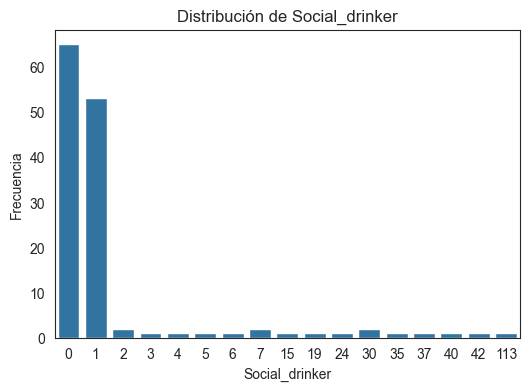

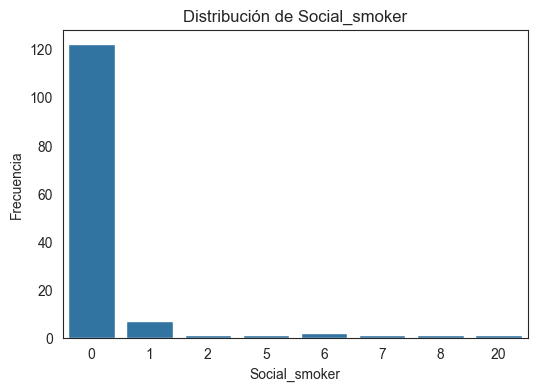

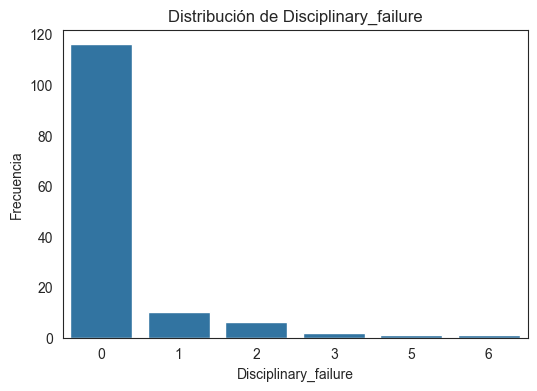

In [9]:
#Cual es la distribución de estos datos? Siguen una distribución de Poisson, binomial, normal, etc? Esto puede ayudar a elegir tests estadísticos más adecuados.
variables_distribucion = ['Social_drinker', 'Social_smoker', 'Disciplinary_failure']
for variable in variables_distribucion:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=variable, data=rrhh_id)
    plt.title(f'Distribución de {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frecuencia')
    plt.show()

## <span style="color: orange; font-size:30px">**Tabla descriptiva de la pregunta de negoció**</span>

In [34]:
variables_habitos = [
    'Social_drinker',
    'Social_smoker',
    'Disciplinary_failure'
]

resumen_habitos = []

for variable in variables_habitos:

    tabla = (
        df_empleados
        .groupby(variable)
        .agg(
            empleados=('ID', 'nunique'),
            horas_totales=('horas_totales', 'sum'),
            media_horas=('horas_totales', 'mean'),
            mediana_horas=('horas_totales', 'median'),
            q1=('horas_totales', lambda x: x.quantile(0.25)),
            q3=('horas_totales', lambda x: x.quantile(0.75))
        )
        .reset_index()
    )

    tabla['variable'] = variable

    resumen_habitos.append(tabla)

resumen_habitos = pd.concat(resumen_habitos)

resumen_habitos

,Social_drinker,empleados,horas_totales,media_horas,mediana_horas,q1,q3,variable,Social_smoker,Disciplinary_failure
0,0.0,65,2459,37.830769,8.0,2.00,16.00,Social_drinker,NaN,NaN
1,1.0,71,3767,53.056338,8.0,2.00,16.00,Social_drinker,NaN,NaN
0,NaN,122,5835,47.827869,7.0,2.00,8.00,Social_smoker,0.0,NaN
1,NaN,14,391,27.928571,12.0,8.00,30.75,Social_smoker,1.0,NaN
0,NaN,116,2828,24.379310,4.0,2.00,8.00,Disciplinary_failure,NaN,0.0
1,NaN,20,3398,169.900000,111.0,28.75,267.00,Disciplinary_failure,NaN,1.0


   - <span style="color:orange; font-size:16px">**Mann-Whitney U test**</span>

In [42]:
# Como hacer el Mann-Whitney U test para cada variable de hábito vs horas_totales, y mostrar los resultados en un DataFrame ordenado por p-value.
variables_habitos = [
    'Social_drinker',
    'Social_smoker',
    'Disciplinary_failure'
]

mann_habitos = []
for variable in variables_habitos:
    grupo_0 = df_empleados[df_empleados[variable] == 0]['horas_totales']
    grupo_1 = df_empleados[df_empleados[variable] == 1]['horas_totales']

    stat, p_value = mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')

    mann_habitos.append({
        'variable': variable,
        'U_statistic': round(stat, 2),
        'p_value': round(p_value, 4),
        'significativo_p_005': 'Sí' if p_value < 0.05 else 'No'
    })

mann_habitos = pd.DataFrame(mann_habitos)
mann_habitos = mann_habitos.sort_values(by='p_value')
mann_habitos

,variable,U_statistic,p_value,significativo_p_005
2,Disciplinary_failure,292.5,0.0000,Sí
1,Social_smoker,563.5,0.0353,Sí
0,Social_drinker,2212.0,0.6749,No


In [45]:
#Cuantos empleados son fumadores sociales y cuantos no? 
df_empleados['Social_smoker'].value_counts()

Social_smoker
0    122
1     14
Name: count, dtype: int64

In [46]:
df_empleados['Social_drinker'].value_counts()

Social_drinker
1    71
0    65
Name: count, dtype: int64

In [47]:
df_empleados['Disciplinary_failure'].value_counts()

Disciplinary_failure
0    116
1     20
Name: count, dtype: int64

<span style="font-size:14px">Según el resultado del test de Mann-Whitney U:

- `Fumadores sociales` muestra una diferencia significativa en horas de absentismo entre el grupo de fumadores y el de no fumadores. Pero el grupo de fumadores sociales en comparación con el grupo de NO fumadores sociales es bastante dispar, por lo que no se puede afirmar que el consumo social de tabaco sea un factor determinante del absentismo.
- `Bebedores sociales` no muestra una diferencia significativa en horas de absentismo entre el grupo de bebedores (71 empleados) y el de no bebedores (65 empleados), por lo que no se puede afirmar que el consumo social de alcohol sea un factor determinante del absentismo. Aquí los grupos están bastante equilibrados por lo que nos podemos fiar más del resultado estadístico. 
- `Faltas disciplinarias` muestra una diferencia significativa en horas de absentismo entre el grupo con antecedentes disciplinarios y el que no muy importante. Nos la podemos creer totalmente porque aunqué la distribución sea de 116 empleados sin antecedentes disciplinarios y 20 con antecedentes disciplinarios, el grupo con antecedentes disciplinarios tiene una media de horas de absentismo mucho más alta que el grupo sin antecedentes disciplinarios. Por lo tanto, se puede afirmar que las faltas disciplinarias son un factor determinante del absentismo.


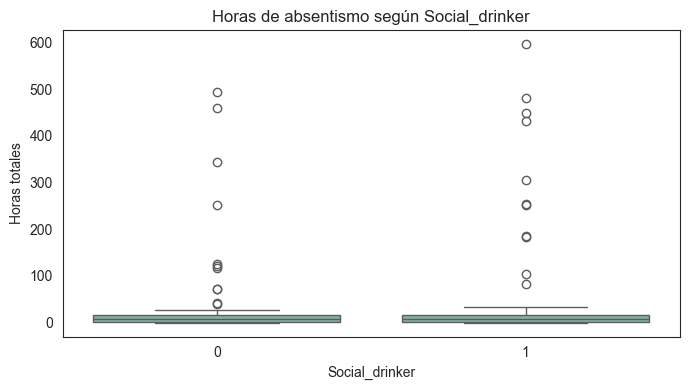

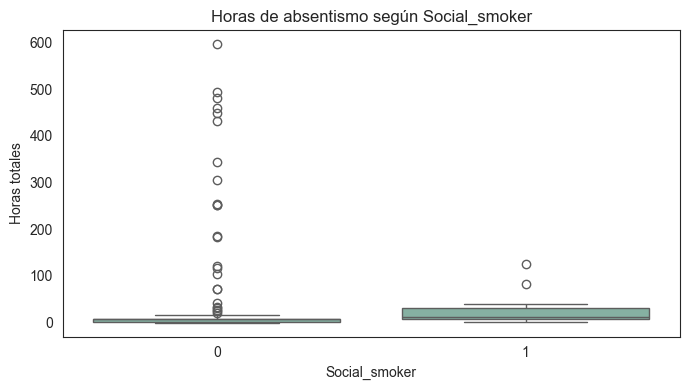

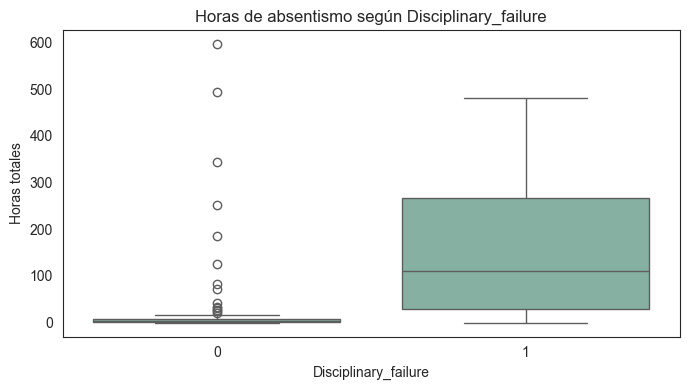

In [38]:
for variable in variables_habitos:

    plt.figure(figsize=(7,4))
    plt.gcf().patch.set_alpha(0)

    ax = plt.gca()
    ax.set_facecolor('none')

    sns.boxplot(
        data=df_empleados,
        x=variable,
        y='horas_totales',
        color=COLOR_VERDE_PRINCIPAL
    )

    plt.title(f'Horas de absentismo según {variable}')
    plt.xlabel(variable)
    plt.ylabel('Horas totales')

    plt.tight_layout()
    plt.show()

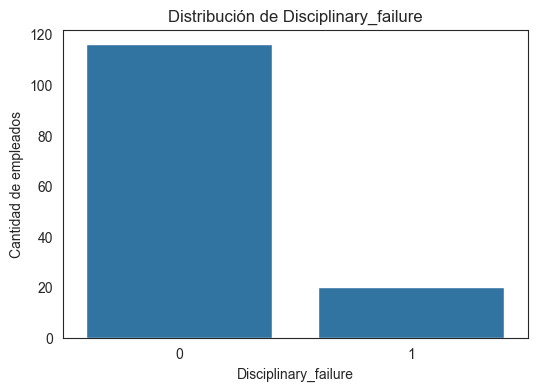

In [39]:
#Como es la distribución de datos en disciplinary_failure?
plt.figure(figsize=(6, 4))
sns.countplot(x='Disciplinary_failure', data=df_empleados)
plt.title('Distribución de Disciplinary_failure')
plt.xlabel('Disciplinary_failure')
plt.ylabel('Cantidad de empleados')
plt.show()